<a href="https://colab.research.google.com/github/Ololade117/Inducing-Polysemanticity/blob/main/Bias_interpretability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Interpretability: Linear Probes and a Sparse Autoencoder

This notebook loads three of the six trained models from the bias-mechanism
experiment -- **normal**, **flex**, and **gated_sigmoid** -- from Hugging Face
Hub, and looks inside them with two standard interpretability tools:

1. **Linear probes**: small linear classifiers trained on top of *frozen*
   internal activations, to test whether a property is linearly decodable
   from the model's representations at each layer. Two probes here:
   - **Position-in-context**: does the residual stream at each block encode
     *which* of the `BLOCK_SIZE` context positions a token sits at?
   - **Word-boundary**: right before the model predicts the next token, does
     its representation linearly encode whether that next token starts a new
     word (vs. continues the current one)?
2. **Sparse Autoencoder (SAE)**: trained on the MLP's hidden activations
   (specifically `mlp_in`'s output, post-GELU -- the exact layer where the six
   bias mechanisms actually differ from each other), to decompose a dense
   256-unit activation into a much larger, sparser set of features that are
   hopefully easier to interpret individually. For a few features, we look at
   which tokens/contexts activate them most strongly.

This is a separate, self-contained notebook -- it re-defines the model classes
and re-trains the tokenizer (deterministically, so it reproduces exactly) so
it can run independently of the training notebook, needing only the three
pushed model checkpoints.


## 0. Setup, data, tokenizer, and architecture

These four cells are copied verbatim from the training notebook -- the model
classes especially need to match *exactly*, since `from_pretrained` uses them
to reconstruct the saved checkpoints. The tokenizer is retrained rather than
saved/reloaded: BPE training is deterministic given the same corpus and target
vocab size, so retraining it here reproduces the identical tokenizer used
during training, with no separate artifact to manage.


In [1]:
# If a package is missing, uncomment and run:
# !pip install -q torch huggingface_hub matplotlib

import urllib.request
from collections import Counter

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from huggingface_hub import PyTorchModelHubMixin, notebook_login

torch.manual_seed(42)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

HF_USERNAME = "Ololade117"   # <-- replace with your Hugging Face username
PUSH_TO_HUB = True                 # set False to skip the upload steps while testing

# Run this once, then paste a Hugging Face token with write access when prompted.
# notebook_login()


Using device: cuda


In [2]:
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
text = urllib.request.urlopen(url).read().decode("utf-8")
print(f"{len(text):,} characters, e.g.:\n{text[:200]!r}")

# Drop near-singleton characters: a handful of formatting/typo artifacts (a
# stray scene-heading digit, a lone '$', three '&'s) rather than let a few
# classes into the vocab that appear 1-27 times across 1.1M characters and
# can never be learned -- they'd just be dead weight in the output layer.
MIN_CHAR_COUNT = 30
counts = Counter(text)
dropped = {ch for ch, n in counts.items() if n < MIN_CHAR_COUNT}
if dropped:
    print(f"\nDropping {len(dropped)} near-singleton characters {sorted(dropped)!r} "
          f"({sum(counts[c] for c in dropped)} occurrences out of {len(text):,})")
    text = "".join(ch for ch in text if ch not in dropped)

n1 = int(0.8 * len(text))
n2 = int(0.9 * len(text))
train_text, val_text, test_text = text[:n1], text[n1:n2], text[n2:]
print("train/val/test characters:", len(train_text), len(val_text), len(test_text))


1,115,394 characters, e.g.:
'First Citizen:\nBefore we proceed any further, hear me speak.\n\nAll:\nSpeak, speak.\n\nFirst Citizen:\nYou are all resolved rather to die than to famish?\n\nAll:\nResolved. resolved.\n\nFirst Citizen:\nFirst, you'

Dropping 3 near-singleton characters ['$', '&', '3'] (31 occurrences out of 1,115,394)
train/val/test characters: 892290 111536 111537


In [3]:
import re

GPT2_SPLIT_PATTERN = r"""'s|'t|'re|'ve|'m|'ll|'d| ?[a-zA-Z]+| ?[0-9]+| ?[^\sa-zA-Z0-9]+|\s+(?!\S)|\s+"""


class BPETokenizer:
    """
    Byte-level BPE tokenizer, trained from scratch -- the same core algorithm
    behind GPT-2/GPT-4's tokenizers, including their regex pre-splitting:
    text is chunked into word-like pieces first, and merges never cross a
    chunk boundary. That's what lets a small custom vocabulary converge on
    whole words instead of getting stuck on arbitrary byte pairs.
    """

    def __init__(self):
        self.merges = {}                                  # (id1, id2) -> new_id, in learn order
        self.vocab = {i: bytes([i]) for i in range(256)}   # id -> raw bytes
        self.pattern = re.compile(GPT2_SPLIT_PATTERN)

    @property
    def vocab_size(self):
        return len(self.vocab)

    @staticmethod
    def _merge(ids, pair, new_id):
        new_ids, i, n = [], 0, len(ids)
        while i < n:
            if i < n - 1 and ids[i] == pair[0] and ids[i + 1] == pair[1]:
                new_ids.append(new_id)
                i += 2
            else:
                new_ids.append(ids[i])
                i += 1
        return new_ids

    @staticmethod
    def _merge_and_update_counts(ids, pair, new_id, counts):
        """Same merge as `_merge`, but updates `counts` in place for exactly
        the pairs that changed, instead of recounting everything from scratch."""
        new_ids, i, n = [], 0, len(ids)
        while i < n:
            if i < n - 1 and ids[i] == pair[0] and ids[i + 1] == pair[1]:
                if new_ids:
                    left = new_ids[-1]
                    counts[(left, pair[0])] = counts.get((left, pair[0]), 0) - 1
                    counts[(left, new_id)] = counts.get((left, new_id), 0) + 1
                if i + 2 < n:
                    right = ids[i + 2]
                    counts[(pair[1], right)] = counts.get((pair[1], right), 0) - 1
                    counts[(new_id, right)] = counts.get((new_id, right), 0) + 1
                new_ids.append(new_id)
                i += 2
            else:
                new_ids.append(ids[i])
                i += 1
        return new_ids

    def train(self, text, vocab_size, verbose=False):
        assert vocab_size >= 256, "vocab_size must cover at least the raw byte values"
        chunks = [list(chunk.encode("utf-8")) for chunk in self.pattern.findall(text)]

        counts = {}
        for ids in chunks:
            for a, b in zip(ids, ids[1:]):
                counts[(a, b)] = counts.get((a, b), 0) + 1

        num_merges = vocab_size - 256
        for i in range(num_merges):
            counts = {k: v for k, v in counts.items() if v > 0}
            if not counts:
                break
            pair = max(counts, key=counts.get)
            new_id = 256 + i
            chunks = [self._merge_and_update_counts(ids, pair, new_id, counts) for ids in chunks]
            counts.pop(pair, None)
            self.merges[pair] = new_id
            self.vocab[new_id] = self.vocab[pair[0]] + self.vocab[pair[1]]
            if verbose and (i + 1) % 128 == 0:
                print(f"  merge {i+1:4d}/{num_merges}: {pair} -> {new_id}  {self.vocab[new_id]!r}")

    def encode(self, text):
        ids = []
        for chunk in self.pattern.findall(text):
            chunk_ids = list(chunk.encode("utf-8"))
            for pair, new_id in self.merges.items():  # replay merges in the order learned
                chunk_ids = self._merge(chunk_ids, pair, new_id)
            ids.extend(chunk_ids)
        return ids

    def decode(self, ids):
        raw = b"".join(self.vocab[i] for i in ids)
        return raw.decode("utf-8", errors="replace")


TOKENIZER_VOCAB_SIZE = 1024  # 256 base bytes + 768 learned merges -- see markdown above for why

tokenizer = BPETokenizer()
tokenizer.train(train_text, vocab_size=TOKENIZER_VOCAB_SIZE, verbose=True)

train_data = torch.tensor(tokenizer.encode(train_text), dtype=torch.long)
val_data = torch.tensor(tokenizer.encode(val_text), dtype=torch.long)
test_data = torch.tensor(tokenizer.encode(test_text), dtype=torch.long)
VOCAB_SIZE = tokenizer.vocab_size

print(f"\nvocab_size = {VOCAB_SIZE} (256 base bytes + {len(tokenizer.merges)} merges)")
print(f"train/val/test tokens: {len(train_data):,} / {len(val_data):,} / {len(test_data):,}")
print(f"compression: {len(train_text) / len(train_data):.2f} characters per token")

common_words = [" the", " and", " you", " that", " with", " your", " thou", " love",
                 " lord", " king", " thee", " shall"]
hits = [w for w in common_words if w.encode("utf-8") in tokenizer.vocab.values()]
print(f"\nwhole-word check: {len(hits)}/{len(common_words)} common words became single "
      f"tokens: {[w.strip() for w in hits]}")


  merge  128/768: (276, 111) -> 383  b' do'
  merge  256/768: (404, 293) -> 511  b' love'
  merge  384/768: (638, 418) -> 639  b'GLOUCESTER'
  merge  512/768: (262, 538) -> 767  b' most'
  merge  640/768: (716, 416) -> 895  b'NTES'
  merge  768/768: (560, 422) -> 1023  b'cious'

vocab_size = 1024 (256 base bytes + 768 merges)
train/val/test tokens: 364,506 / 47,489 / 49,880
compression: 2.45 characters per token

whole-word check: 12/12 common words became single tokens: ['the', 'and', 'you', 'that', 'with', 'your', 'thou', 'love', 'lord', 'king', 'thee', 'shall']


In [4]:
class ManualLinear(nn.Module):
    """
    One h = h @ W + b step. `bias_type` selects which of the six bias
    mechanisms this layer uses -- every mechanism is defined right here.
    """

    def __init__(self, in_dim, out_dim, bias_type="normal", block_size=None):
        super().__init__()
        self.bias_type = bias_type
        self.weight = nn.Parameter(torch.randn(in_dim, out_dim) * in_dim ** -0.5)

        if bias_type == "normal":
            self.bias = nn.Parameter(torch.zeros(out_dim))

        elif bias_type in ("gated_sigmoid", "gated_relu", "gated_tanh"):
            self.bias = nn.Parameter(torch.zeros(out_dim))
            self.gate_param = nn.Parameter(torch.zeros(out_dim))  # learned, pre-activation

        elif bias_type == "per_position":
            assert block_size is not None, "per_position bias needs block_size"
            self.bias = nn.Parameter(torch.zeros(block_size, out_dim))

        elif bias_type == "flex":
            # maps h itself down to one scalar per row (per example, per position)
            self.flex_vec = nn.Parameter(torch.zeros(in_dim, 1))

        else:
            raise ValueError(f"Unknown bias_type: {bias_type!r}")

    def forward(self, h):
        out = h @ self.weight

        if self.bias_type == "normal":
            return out + self.bias

        elif self.bias_type == "gated_sigmoid":
            return out + torch.sigmoid(self.gate_param) * self.bias

        elif self.bias_type == "gated_relu":
            return out + torch.relu(self.gate_param) * self.bias

        elif self.bias_type == "gated_tanh":
            return out + torch.tanh(self.gate_param) * self.bias

        elif self.bias_type == "per_position":
            # self.bias: (block_size, out_dim) broadcasts over the batch dim
            return out + self.bias

        elif self.bias_type == "flex":
            flex_bias = h @ self.flex_vec  # (..., 1) -- one value per row
            return out + flex_bias

        else:
            raise ValueError(f"Unknown bias_type: {self.bias_type!r}")


class CausalSelfAttention(nn.Module):
    """
    Standard multi-head causal self-attention. Plain nn.Linear projections,
    deliberately NOT varied by bias_type -- isolating the bias experiment to
    the MLP sublayer, same reasoning as the output head staying "normal".
    """

    def __init__(self, d_model, n_head, block_size):
        super().__init__()
        assert d_model % n_head == 0, "d_model must be divisible by n_head"
        self.n_head = n_head
        self.head_dim = d_model // n_head
        self.qkv = nn.Linear(d_model, 3 * d_model)
        self.proj = nn.Linear(d_model, d_model)

    def forward(self, x):
        B, T, C = x.shape
        q, k, v = self.qkv(x).split(C, dim=2)
        q = q.view(B, T, self.n_head, self.head_dim).transpose(1, 2)  # (B, nh, T, hd)
        k = k.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        y = F.scaled_dot_product_attention(q, k, v, is_causal=True)   # handles the causal mask
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        return self.proj(y)


class TransformerBlock(nn.Module):
    """
    x = x + attn(ln(x));  x = x + mlp(ln(x)) -- the bias experiment lives
    entirely inside the MLP's two ManualLinear layers.
    """

    def __init__(self, d_model, n_head, block_size, bias_name):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = CausalSelfAttention(d_model, n_head, block_size)
        self.ln2 = nn.LayerNorm(d_model)
        self.mlp_in = ManualLinear(d_model, 4 * d_model, bias_type=bias_name, block_size=block_size)
        self.mlp_out = ManualLinear(4 * d_model, d_model, bias_type=bias_name, block_size=block_size)

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        h = F.gelu(self.mlp_in(self.ln2(x)))
        x = x + self.mlp_out(h)
        return x


class NormalBiasNet(
    nn.Module,
    PyTorchModelHubMixin,
    license="mit",
):
    """
    A small transformer. `bias_name` picks the bias mechanism used by every
    MLP sublayer (see ManualLinear/TransformerBlock above) -- attention, layer
    norms, and the output head stay identical across all six networks built
    later in this notebook.
    """

    def __init__(self, vocab_size, hidden_dim, n_head, block_size, n_layers=3, bias_name="normal"):
        super().__init__()
        self.vocab_size = vocab_size
        self.hidden_dim = hidden_dim  # this is d_model -- the one dimension carried through the residual stream
        self.n_head = n_head
        self.block_size = block_size
        self.n_layers = n_layers
        self.bias_name = bias_name

        self.token_emb = nn.Parameter(torch.randn(vocab_size, hidden_dim) * 0.02)
        self.pos_emb = nn.Parameter(torch.randn(block_size, hidden_dim) * 0.02)

        self.blocks = nn.ModuleList([
            TransformerBlock(hidden_dim, n_head, block_size, bias_name) for _ in range(n_layers)
        ])
        self.ln_f = nn.LayerNorm(hidden_dim)

        # The output head always uses a plain bias -- same reasoning as before.
        self.out = ManualLinear(hidden_dim, vocab_size, bias_type="normal")

    def forward(self, X):
        B, T = X.shape
        x = self.token_emb[X] + self.pos_emb[:T]   # (batch, block_size, hidden_dim)

        for block in self.blocks:
            x = block(x)
        x = self.ln_f(x)

        x = x[:, -1, :]           # attention already mixed in every earlier position
        logits = self.out(x)      # raw logits -- loss fn applies softmax
        return logits


# Shared hyperparameters -- identical for all six models below, so the *only*
# thing that differs between them is the bias mechanism.
#
# EMBED_DIM is gone: a transformer needs one consistent dimension (d_model)
# carried through the whole residual stream, so HIDDEN_DIM now plays that role
# directly, from the token embedding through every block. N_HEAD is new --
# must evenly divide HIDDEN_DIM.
#
# Because attention lets the last position see every earlier one, the output
# layer no longer needs the whole context concatenated into it -- it drops
# from hidden_dim*block_size*vocab_size to just hidden_dim*vocab_size. That's
# the single biggest change from every earlier version of this notebook: the
# output layer goes from ~86% of the model back down to under 10%.
BLOCK_SIZE = 6
HIDDEN_DIM = 256
N_HEAD = 4
N_LAYERS = 4
STEPS = 15000
BATCH_SIZE = 256
LR = 2e-3


## 1. Load the three trained models from Hugging Face Hub

Set `HF_USERNAME` to whatever was used when pushing the models during
training -- these load via the same `PyTorchModelHubMixin.from_pretrained`
that `push_to_hub` set up. `.eval()` puts each model in inference mode
(matters here since it disables dropout/etc. if any were added later).

The hyperparameters are passed explicitly rather than relying solely on the
repo's saved `config.json` -- harmless if the config is fine, and it's the
difference between working and not if a repo's config/upload didn't fully
complete (e.g. after an earlier token-permission hiccup during push_to_hub).


In [5]:
HF_USERNAME = "Ololade117"  # <-- same username used when pushing the models

BIAS_TYPES_TO_LOAD = ["normal", "flex", "gated_sigmoid"]

models = {}
for bias_type in BIAS_TYPES_TO_LOAD:
    repo_id = f"{HF_USERNAME}/shakespeare-bias-{bias_type.replace('_', '-')}"
    model = NormalBiasNet.from_pretrained(
        repo_id,
        vocab_size=VOCAB_SIZE, hidden_dim=HIDDEN_DIM, n_head=N_HEAD,
        block_size=BLOCK_SIZE, n_layers=N_LAYERS, bias_name=bias_type,
    )
    model.to(DEVICE).eval()
    models[bias_type] = model
    n_params = sum(p.numel() for p in model.parameters())
    print(f"loaded {bias_type:15s} from {repo_id}  ({n_params:,} params)")


config.json:   0%|          | 0.00/121 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 14.8MB            

model.safetensors: downloading bytes:           |  0.00B            

loaded normal          from Ololade117/shakespeare-bias-normal  (3,686,400 params)


config.json:   0%|          | 0.00/119 [00:00<?, ?B/s]

...

loaded flex            from Ololade117/shakespeare-bias-flex  (3,686,400 params)


config.json:   0%|          | 0.00/128 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 14.8MB            

model.safetensors: downloading bytes:           |  0.00B            

loaded gated_sigmoid   from Ololade117/shakespeare-bias-gated-sigmoid  (3,691,520 params)


## 2. Activation-extraction utilities

Forward hooks let us read a module's output during a normal forward pass
without changing `forward()` at all. `get_activations` hooks whichever
submodules you name, runs the model once, and hands back everything it
captured.


In [6]:
def get_activations(model, X, named_modules):
    # named_modules: list of (name, module) pairs to capture the output of.
    # Returns (dict name -> activation tensor, logits).
    captured = {}
    handles = []

    def make_hook(name):
        def hook(module, inputs, output):
            captured[name] = output.detach()
        return hook

    for name, module in named_modules:
        handles.append(module.register_forward_hook(make_hook(name)))

    with torch.no_grad():
        logits = model(X)

    for h in handles:
        h.remove()

    return captured, logits


def collect_activations(model, X, batch_size=256):
    # Captures every block's residual-stream output (for the position probe)
    # and every block's mlp_in output (for the SAE and the word-boundary
    # probe reads block outputs directly, mlp_in is only used by the SAE).
    named_modules = (
        [(f"block{i}", model.blocks[i]) for i in range(model.n_layers)]
        + [(f"block{i}_mlpin", model.blocks[i].mlp_in) for i in range(model.n_layers)]
    )
    buffers = {name: [] for name, _ in named_modules}
    for i in range(0, X.shape[0], batch_size):
        Xb = X[i:i + batch_size].to(DEVICE)
        captured, _ = get_activations(model, Xb, named_modules)
        for name in buffers:
            buffers[name].append(captured[name].cpu())
    return {name: torch.cat(v, dim=0) for name, v in buffers.items()}


## 3. Build the probing dataset

Sample a few thousand random context windows from `val_data` (held-out text,
same as training used for evaluation), then collect every model's
activations on the exact same windows -- so any difference between models
reflects the models themselves, not different input data.


In [7]:
N_PROBE_WINDOWS = 3000

def sample_windows(data, block_size, n):
    ix = torch.randint(0, len(data) - block_size - 1, (n,))
    idx = ix.unsqueeze(1) + torch.arange(block_size)
    X = data[idx]
    Y = data[ix + block_size]
    return X, Y

torch.manual_seed(0)
Xp, Yp = sample_windows(val_data, BLOCK_SIZE, N_PROBE_WINDOWS)
print(f"probing dataset: {Xp.shape[0]:,} windows of {BLOCK_SIZE} tokens each")

# Label 1: which position (0..BLOCK_SIZE-1) does each token sit at?
position_labels = torch.arange(BLOCK_SIZE).unsqueeze(0).expand(N_PROBE_WINDOWS, BLOCK_SIZE).reshape(-1)

# Label 2: does the actual next token (Y) start a new word, i.e. does its
# byte string begin with a space? (This tokenizer's chunking means a token
# starting a new word always begins with the space that preceded it.)
newword_labels = torch.tensor(
    [1 if tokenizer.vocab[y.item()][:1] == b" " else 0 for y in Yp], dtype=torch.long
)
print(f"word-boundary label balance: {newword_labels.float().mean():.2f} start a new word")

activations = {name: collect_activations(model, Xp) for name, model in models.items()}
print("collected activations for:", list(activations.keys()))


probing dataset: 3,000 windows of 6 tokens each
word-boundary label balance: 0.36 start a new word
collected activations for: ['normal', 'flex', 'gated_sigmoid']


## 4. Linear probes

A small `nn.Linear` trained with cross-entropy on frozen activations, tested
on a held-out split. Accuracy well above chance means the property is
(at least partly) linearly decodable from that layer's representation.


In [8]:
def train_linear_probe(X, y, n_classes, steps=300, lr=1e-2, test_frac=0.2):
    N = X.shape[0]
    perm = torch.randperm(N)
    n_test = int(N * test_frac)
    test_idx, train_idx = perm[:n_test], perm[n_test:]
    Xtr, ytr = X[train_idx].to(DEVICE), y[train_idx].to(DEVICE)
    Xte, yte = X[test_idx].to(DEVICE), y[test_idx].to(DEVICE)

    probe = nn.Linear(X.shape[1], n_classes).to(DEVICE)
    opt = optim.Adam(probe.parameters(), lr=lr)
    for _ in range(steps):
        opt.zero_grad()
        loss = F.cross_entropy(probe(Xtr), ytr)
        loss.backward()
        opt.step()

    with torch.no_grad():
        acc = (probe(Xte).argmax(-1) == yte).float().mean().item()
    return acc


In [9]:
position_acc = {name: [] for name in models}
newword_acc = {name: [] for name in models}

for name in models:
    for i in range(N_LAYERS):
        block_out = activations[name][f"block{i}"]           # (N, T, hidden_dim)

        # Probe A: position-in-context, using every position in every window
        X_pos = block_out.reshape(-1, block_out.shape[-1])
        y_pos = position_labels
        acc_pos = train_linear_probe(X_pos, y_pos, n_classes=BLOCK_SIZE)
        position_acc[name].append(acc_pos)

        # Probe B: word-boundary, using only the LAST position (what the
        # model actually bases its next-token prediction on)
        X_last = block_out[:, -1, :]
        acc_new = train_linear_probe(X_last, newword_labels, n_classes=2)
        newword_acc[name].append(acc_new)

    print(f"{name:15s} position-probe acc by block: {[f'{a:.2f}' for a in position_acc[name]]}")
    print(f"{'':15s} word-boundary acc by block:  {[f'{a:.2f}' for a in newword_acc[name]]}")


normal          position-probe acc by block: ['0.93', '0.92', '0.89', '0.86']
                word-boundary acc by block:  ['0.79', '0.80', '0.84', '0.81']
flex            position-probe acc by block: ['0.92', '0.91', '0.88', '0.87']
                word-boundary acc by block:  ['0.82', '0.84', '0.81', '0.81']
gated_sigmoid   position-probe acc by block: ['0.97', '0.96', '0.95', '0.94']
                word-boundary acc by block:  ['0.80', '0.79', '0.78', '0.84']


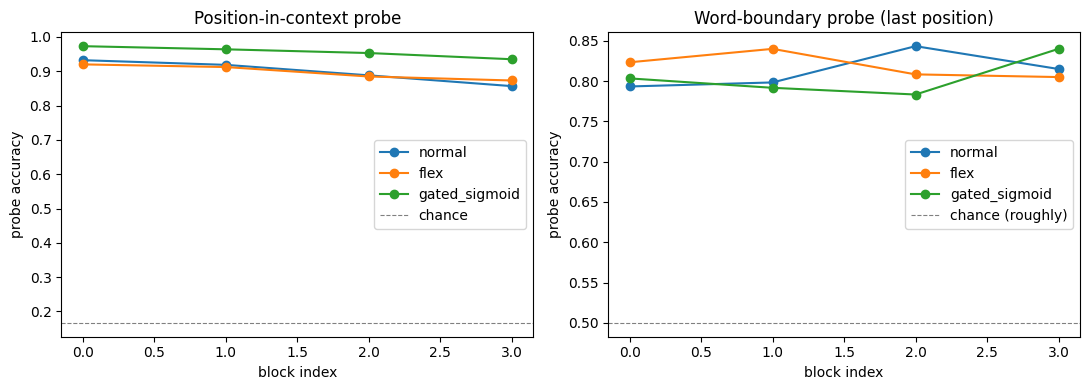

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for name in models:
    axes[0].plot(range(N_LAYERS), position_acc[name], marker="o", label=name)
    axes[1].plot(range(N_LAYERS), newword_acc[name], marker="o", label=name)

axes[0].axhline(1 / BLOCK_SIZE, color="gray", linestyle="--", linewidth=0.8, label="chance")
axes[0].set_title("Position-in-context probe")
axes[0].set_xlabel("block index"); axes[0].set_ylabel("probe accuracy")
axes[0].legend()

axes[1].axhline(0.5, color="gray", linestyle="--", linewidth=0.8, label="chance (roughly)")
axes[1].set_title("Word-boundary probe (last position)")
axes[1].set_xlabel("block index"); axes[1].set_ylabel("probe accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()


**A note on what to expect from the position probe**: every model gets a
learned positional embedding added directly at the input, and residual
connections give that signal a "shortcut" path to every later layer -- so
high accuracy at every block, for all three models, is the expected baseline
result, not evidence of anything special. What's actually informative here is
*relative* differences: does accuracy decay across depth, and does it decay
differently for `normal` vs. `flex` vs. `gated_sigmoid`? The word-boundary
probe is the more genuinely open question, since nothing in the architecture
directly injects that information -- it has to be learned.


## 5. Sparse Autoencoder

Trained on `mlp_in`'s output (after GELU) from one representative middle
block -- the exact activation whose *bias* differs across the three models,
even though the surrounding architecture is identical. The SAE's hidden
dimension is deliberately much larger than the input (`SAE_HIDDEN_MULT`x),
with an L1 penalty encouraging most features to be zero for any given input --
the idea being that a sparse, overcomplete basis is more likely to align with
individually-interpretable directions than the dense original activation.


In [11]:
class SparseAutoencoder(nn.Module):
    # f = relu((x - b_dec) @ W_enc + b_enc)   -- encode, d_in -> d_hidden
    # x_hat = f @ W_dec + b_dec               -- decode, d_hidden -> d_in
    # loss = mse(x, x_hat) + l1_coeff * mean(|f|)

    def __init__(self, d_in, d_hidden):
        super().__init__()
        self.W_enc = nn.Parameter(torch.randn(d_in, d_hidden) * d_in ** -0.5)
        self.b_enc = nn.Parameter(torch.zeros(d_hidden))
        self.W_dec = nn.Parameter(torch.randn(d_hidden, d_in) * d_hidden ** -0.5)
        self.b_dec = nn.Parameter(torch.zeros(d_in))

    def encode(self, x):
        return F.relu((x - self.b_dec) @ self.W_enc + self.b_enc)

    def decode(self, f):
        return f @ self.W_dec + self.b_dec

    def forward(self, x):
        f = self.encode(x)
        return self.decode(f), f


def train_sae(acts, d_hidden, steps=2000, batch_size=256, lr=1e-3, l1_coeff=1e-3, log_every=400):
    acts = acts.to(DEVICE)
    sae = SparseAutoencoder(acts.shape[1], d_hidden).to(DEVICE)
    opt = optim.Adam(sae.parameters(), lr=lr)
    history = {"step": [], "recon": [], "l1": [], "frac_active": []}
    for step in range(1, steps + 1):
        ix = torch.randint(0, acts.shape[0], (batch_size,))
        x = acts[ix]
        x_hat, f = sae(x)
        recon_loss = F.mse_loss(x_hat, x)
        l1_loss = f.abs().mean()
        loss = recon_loss + l1_coeff * l1_loss

        opt.zero_grad()
        loss.backward()
        opt.step()

        if step % log_every == 0 or step == 1:
            frac_active = (f > 0).float().mean().item()
            history["step"].append(step)
            history["recon"].append(recon_loss.item())
            history["l1"].append(l1_loss.item())
            history["frac_active"].append(frac_active)
            print(f"  step {step:5d} | recon {recon_loss.item():.4f} | L1 {l1_loss.item():.4f} "
                  f"| fraction of features active {frac_active:.3f}")
    return sae, history


In [12]:
SAE_BLOCK_IDX = N_LAYERS // 2   # a representative middle block
SAE_HIDDEN_MULT = 4

def collect_mlp_activations_with_context(model, X, block_idx, batch_size=256):
    layer_name = f"block{block_idx}_mlpin"
    module = model.blocks[block_idx].mlp_in
    acts, source_tokens, contexts = [], [], []
    for i in range(0, X.shape[0], batch_size):
        Xb = X[i:i + batch_size]
        captured, _ = get_activations(model, Xb.to(DEVICE), [(layer_name, module)])
        a = F.gelu(captured[layer_name]).cpu()          # (b, block_size, 4*hidden_dim)
        acts.append(a.reshape(-1, a.shape[-1]))
        for b in range(Xb.shape[0]):
            for t in range(Xb.shape[1]):
                source_tokens.append(Xb[b, t].item())
                contexts.append(tokenizer.decode(Xb[b, :t + 1].tolist()))
    return torch.cat(acts, dim=0), source_tokens, contexts


sae_results = {}
for name, model in models.items():
    print(f"\n=== training SAE for {name} (block {SAE_BLOCK_IDX}) ===")
    acts, source_tokens, contexts = collect_mlp_activations_with_context(model, Xp, SAE_BLOCK_IDX)
    sae, history = train_sae(acts, d_hidden=acts.shape[1] * SAE_HIDDEN_MULT)
    sae_results[name] = dict(sae=sae, history=history, acts=acts, tokens=source_tokens, contexts=contexts)



=== training SAE for normal (block 2) ===
  step     1 | recon 0.9762 | L1 0.2967 | fraction of features active 0.499
  step   400 | recon 0.0160 | L1 0.2849 | fraction of features active 0.461
  step   800 | recon 0.0081 | L1 0.3253 | fraction of features active 0.501
  step  1200 | recon 0.0053 | L1 0.3045 | fraction of features active 0.503
  step  1600 | recon 0.0052 | L1 0.2882 | fraction of features active 0.498
  step  2000 | recon 0.0050 | L1 0.2933 | fraction of features active 0.494

=== training SAE for flex (block 2) ===
  step     1 | recon 0.6032 | L1 0.1994 | fraction of features active 0.500
  step   400 | recon 0.0179 | L1 0.1588 | fraction of features active 0.433
  step   800 | recon 0.0195 | L1 0.1550 | fraction of features active 0.435
  step  1200 | recon 0.0081 | L1 0.1338 | fraction of features active 0.423
  step  1600 | recon 0.0077 | L1 0.1407 | fraction of features active 0.417
  step  2000 | recon 0.0096 | L1 0.1177 | fraction of features active 0.387

===

### SAE training curves

Reconstruction loss should trend down; the L1 term will often creep back up a
bit as training proceeds and the SAE trades a little sparsity for a little
more accuracy -- that's expected, not a sign of a bug.


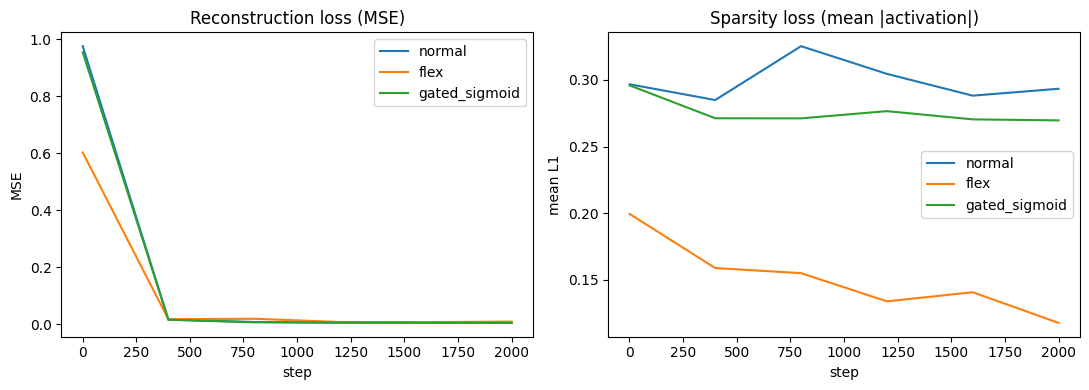

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for name, result in sae_results.items():
    h = result["history"]
    axes[0].plot(h["step"], h["recon"], label=name)
    axes[1].plot(h["step"], h["l1"], label=name)

axes[0].set_title("Reconstruction loss (MSE)")
axes[0].set_xlabel("step"); axes[0].set_ylabel("MSE")
axes[0].legend()

axes[1].set_title("Sparsity loss (mean |activation|)")
axes[1].set_xlabel("step"); axes[1].set_ylabel("mean L1")
axes[1].legend()

plt.tight_layout()
plt.show()


### Feature activation frequency

For each SAE, how often does each of its features fire at all (fraction of
examples with a nonzero activation)? This is the standard SAE health check:
a healthy sparse dictionary has most features firing rarely (a long left
tail) with relatively few "dead" features that never fire and few that fire
on nearly everything (which would suggest they aren't sparse/specific at all).


bias type        dead features   total features   dead %
normal                       0             4096     0.0%
flex                         0             4096     0.0%
gated_sigmoid                0             4096     0.0%


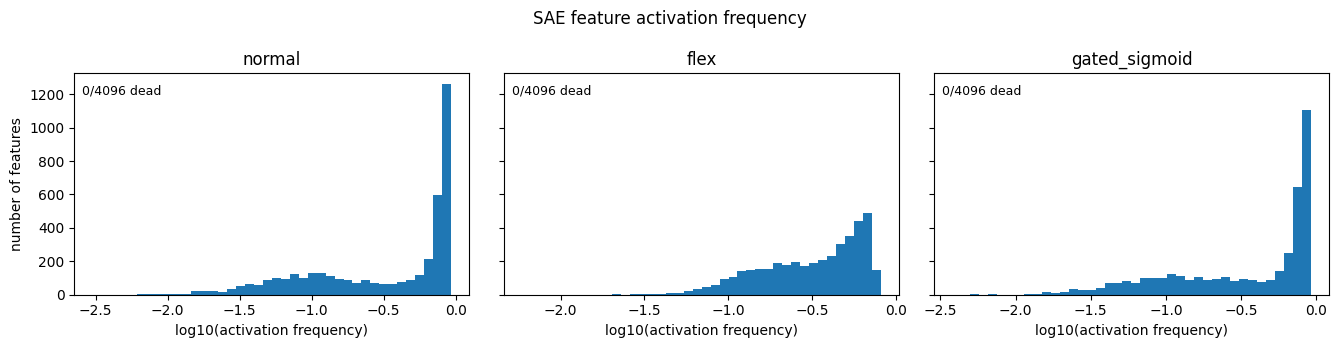

In [14]:
fig, axes = plt.subplots(1, len(sae_results), figsize=(4.5 * len(sae_results), 3.5), sharey=True)
axes = [axes] if len(sae_results) == 1 else axes

print(f"{'bias type':15s} {'dead features':>14s} {'total features':>16s} {'dead %':>8s}")
for ax, (name, result) in zip(axes, sae_results.items()):
    acts = result["acts"].to(DEVICE)
    with torch.no_grad():
        f = result["sae"].encode(acts)
    freq = (f > 0).float().mean(dim=0).cpu()             # (d_hidden,) -- fraction of rows each feature fires on
    n_dead = (freq == 0).sum().item()
    n_total = freq.shape[0]
    print(f"{name:15s} {n_dead:>14d} {n_total:>16d} {100*n_dead/n_total:>7.1f}%")

    freq_nonzero = freq[freq > 0]
    ax.hist(torch.log10(freq_nonzero + 1e-6).numpy(), bins=40)
    ax.set_title(name)
    ax.set_xlabel("log10(activation frequency)")
    ax.text(0.02, 0.95, f"{n_dead}/{n_total} dead", transform=ax.transAxes, va="top", fontsize=9)

axes[0].set_ylabel("number of features")
plt.suptitle("SAE feature activation frequency")
plt.tight_layout()
plt.show()


## 6. Comparing reconstruction quality and sparsity across models

Same SAE architecture, same block index, same input windows -- so any
difference here reflects how "SAE-friendly" (structured/decomposable) each
model's MLP activations are, not a difference in the SAE setup.


In [15]:
print(f"{'bias type':15s} {'recon MSE':>12s} {'mean L1':>10s} {'fraction active':>17s}")
for name, result in sae_results.items():
    acts = result["acts"].to(DEVICE)
    with torch.no_grad():
        x_hat, f = result["sae"](acts)
        recon_mse = F.mse_loss(x_hat, acts).item()
        mean_l1 = f.abs().mean().item()
        frac_active = (f > 0).float().mean().item()
    print(f"{name:15s} {recon_mse:>12.4f} {mean_l1:>10.4f} {frac_active:>17.3f}")


bias type          recon MSE    mean L1   fraction active
normal                0.0051     0.2945             0.495
flex                  0.0116     0.1272             0.383
gated_sigmoid         0.0053     0.2675             0.490


## 7. Max-activating examples for a few SAE features

For a handful of feature indices, find which tokens (in their actual context)
activate that feature most strongly -- the standard first step in interpreting
what an SAE feature represents.


In [16]:
def show_max_activating(result, feature_idx, top_k=8):
    acts = result["acts"].to(DEVICE)
    with torch.no_grad():
        f = result["sae"].encode(acts)[:, feature_idx]
    top = torch.topk(f, top_k)
    for score, idx in zip(top.values.tolist(), top.indices.tolist()):
        tok_str = tokenizer.decode([result["tokens"][idx]])
        ctx = result["contexts"][idx][-40:]
        print(f"  activation={score:6.2f}  token={tok_str!r:12s}  context=...{ctx!r}")


FEATURES_TO_INSPECT = [0, 1, 2]  # pick any indices up to acts.shape[1]*SAE_HIDDEN_MULT - 1

for name, result in sae_results.items():
    print(f"\n=== {name} ===")
    for feat in FEATURES_TO_INSPECT:
        print(f"-- feature {feat} --")
        show_max_activating(result, feat)



=== normal ===
-- feature 0 --
  activation=  8.96  token=' ro'         context=...' the ro'
  activation=  6.82  token=' ro'         context=...' your ro'
  activation=  5.65  token=' ey'         context=...' the ey'
  activation=  5.65  token=' ey'         context=...' the ey'
  activation=  5.46  token='K'           context=...'\nK'
  activation=  5.46  token='K'           context=...'\nK'
  activation=  5.44  token=' ro'         context=...' ro'
  activation=  5.44  token=' ro'         context=...' ro'
-- feature 1 --
  activation=  4.54  token='ell'         context=...'\nWell'
  activation=  4.54  token='ell'         context=...'\nWell'
  activation=  4.29  token='ET'          context=...'\nPET'
  activation=  4.14  token='n'           context=...'\nKn'
  activation=  3.88  token=' j'          context=...' as j'
  activation=  3.82  token=' f'          context=...'And f'
  activation=  3.77  token='r'           context=...'TIO:\nTr'
  activation=  3.66  token='h'           contex

## Wrap-up

What to look for once this has run on your actual pushed models:

- **Position probe**: expect high accuracy everywhere (see the note in
  section 4) -- the interesting signal is whether it *decays* differently
  across the three bias types, not whether it succeeds at all.
- **Word-boundary probe**: this one has no architectural shortcut, so real
  differences in accuracy (or in which block it first becomes decodable)
  would be a genuine finding about how each bias mechanism organizes
  information.
- **SAE reconstruction/sparsity**: a bias mechanism whose MLP activations
  reconstruct better at the same sparsity level is arguably building more
  structured (less entangled) representations at that layer.
- **Max-activating examples**: read a handful across all three models for
  the same feature index -- since the SAEs are trained separately, feature
  *indices* don't correspond to the same concept across models, so compare
  patterns qualitatively (does a model have any clean, single-concept
  features at all?) rather than assuming feature 0 means the same thing
  everywhere.
